In [3]:
from scripts.embedding_model import CLIP_Embedding
import os
from scripts.faiss_search import Faiss_Index
embedding_model = CLIP_Embedding()

dic = {}
path = 'frames/'
idx = 0
for folder in os.listdir(path):
    if os.path.isdir(os.path.join(path, folder)):
        for img in os.listdir(os.path.join(path, folder)):
            if img.endswith('.jpg'):
                dic[f'{idx}'] = os.path.join(path, folder, img)
                idx += 1


index_path = 'faiss_index/index_demo.index'

faiss_index = Faiss_Index(index_path, embedding_model, id2img=dic, load=True)

faiss_index.save_index()

Index loaded from faiss_index/index_demo.index


In [4]:
decription = 'Con tôm hùm đất'
from translate import Translator

translator = Translator(to_lang='en',from_lang='vi')
decription = translator.translate(decription)
print(decription)

Soil scallop shrimp


In [5]:
distance, index = faiss_index.search_text(decription, 20)

print(index[0])

c:\Users\hokha\anaconda3\envs\AIC\Lib\site-packages\torch\nn\functional.py:5504: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


[ 658  558  662  664 2002  675  663  682  684  557  551  726  552  731
  724  722  700 1227 1039   89]


In [6]:
print(distance[0])

[0.1934286  0.18194261 0.18161309 0.1789853  0.17679587 0.17603204
 0.1752043  0.17421223 0.17299473 0.17057663 0.17026526 0.16980788
 0.1678141  0.16472879 0.16342735 0.16191125 0.15954399 0.15914515
 0.15914515 0.15865168]


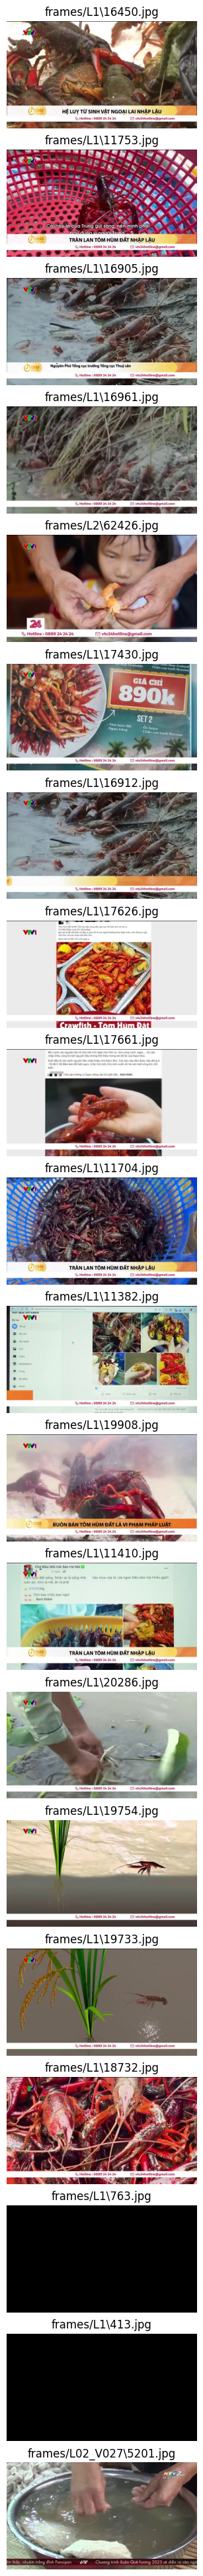

In [7]:
from matplotlib import pyplot as plt
from PIL import Image

fig, ax = plt.subplots(index[0].shape[0], 1, figsize=(50, 50))

for i in range(index[0].shape[0]):
    img = Image.open(dic[f'{index[0][i]}'])
    ax[i].imshow(img)
    ax[i].set_title(f'{dic[f"{index[0][i]}"]}')
    ax[i].axis('off')

plt.show()